<a href="https://colab.research.google.com/github/faisalepty/Sign-Language-CNN/blob/main/train_validate2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, datasets
from torch.utils.data import ConcatDataset, DataLoader, random_split

In [2]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

])

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapillondhe/american-sign-language", output_dir="./data", force_download=True)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'american-sign-language' dataset.
Path to dataset files: /kaggle/input/american-sign-language


In [11]:
path2 = kagglehub.dataset_download("grassknoted/asl-alphabet", output_dir="./data2", force_download=True)

print("Path to dataset files:", path2)

Using Colab cache for faster access to the 'asl-alphabet' dataset.
Path to dataset files: /kaggle/input/asl-alphabet


In [12]:
path3 = kagglehub.dataset_download("debashishsau/aslamerican-sign-language-aplhabet-dataset", output_dir="./data3")

print("Path to dataset files:", path3)

Using Colab cache for faster access to the 'aslamerican-sign-language-aplhabet-dataset' dataset.
Path to dataset files: /kaggle/input/aslamerican-sign-language-aplhabet-dataset


In [ ]:
import shutil
shutil.rmtree("/content/data/ASL_Dataset/Train/.ipynb_checkpoints", ignore_errors=True)

In [ ]:
path = "data"
dataset1 = datasets.ImageFolder("/content/data/ASL_Dataset/Train", transform=val_transforms)
dataset2 = datasets.ImageFolder("/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train", transform=val_transforms)
dataset3 = datasets.ImageFolder("/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train", transform=val_transforms)


dataset = ConcatDataset([dataset1, dataset2, dataset3])

n_total = len(dataset)
n_train = int(0.8*n_total)
n_val = int(n_total - n_train)

train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

In [ ]:
print('Classes in dataset1:', dataset1.classes)
print('Classes in dataset2:', dataset2.classes)
print('Classes in dataset3:', dataset3.classes)


Classes in dataset1: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Classes in dataset2: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Classes in dataset3: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

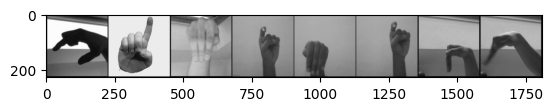

Q     D     M     X     M     X     del   del  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

# Function to unnormalize and display images
def imshow(img):
    # Unnormalize image based on the normalization used in train_transforms
    # The val_transforms are currently applied to the datasets, so I'll use those values for unnormalization.
    # If train_transforms were used for the dataset, the values would be different.
    # The current val_transforms use (0.5,) and (0.5,) for mean and std for grayscale.
    # If the model expects 3 channels, then the transforms for display should reflect that.
    # Given the model 'SignLanguageNet' expects 1 channel (Grayscale), the current val_transforms are appropriate.

    # For a grayscale image with mean 0.5 and std 0.5:
    img = img  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(make_grid(images[:8])) # Displaying first 8 images

# Print labels (assuming class names are available)
classes = dataset1.classes
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5)
        self.conv3 = nn.Conv2d(12, 16, 3)

        self.fc1 = nn.Linear(in_features=10000, out_features=200)
        self.fc2 = nn.Linear(in_features=200, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=29)
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = self.dropout2(x)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SignLanguageNet(nn.Module):
    def __init__(self):
        super(SignLanguageNet, self).__init__()



        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(100352, 512)
        self.fc2 = nn.Linear(512, 29)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = self.pool(F.relu(self.conv3(x)))


        x = torch.flatten(x, 1)


        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [ ]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
# model = LeNet().to(device=device)
model = SignLanguageNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from tqdm import tqdm

In [ ]:
def train(model, train_loader):
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(train_loader, desc="Training", leave=True):
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
  train_loss = running_loss / len(train_loader)
  return train_loss

In [ ]:
def validate(model, val_loader):
  model.eval()
  val_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
      for images, labels in tqdm(val_loader, desc="validating", leave=True):
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          val_loss += loss.item()
          preds = outputs.argmax(dim=1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)
  val_loss /= len(val_loader)
  val_acc = correct / total
  return val_loss, val_acc

In [ ]:
import torch
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
]
)

def predict(image_path, model, transform, device):
    # 1. Load and transform the image
    img = Image.open(image_path)
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img_tensor = transform(img).unsqueeze(0) # Add batch dimension: [1, 3, 128, 128]
    img_tensor = img_tensor.to(device)

    # 2. Set model to evaluation mode
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        # Apply softmax to get probabilities
        probabilities = F.softmax(output, dim=1)
        # Get the predicted class index
        conf, predicted = torch.max(probabilities, 1)

    # 3. Map index to label (ImageFolder usually maps alphabetically)
    # class_names = train_dataset.classes -> ['hotdog', 'not-hotdog']
    labels = dataset1.classes

    print(f"Prediction: {labels[predicted.item()]} ({conf.item()*100:.2f}%)")

# # Usage:
# image_path = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test/Y_test.jpg"
# predict(image_path, model, transform, device)

In [ ]:
epochs = 2
best_val_acc = 0.0

for epoch in range(epochs):
    train_loss = train(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "best_model.pth")



    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")



validating: 100%|██████████| 755/755 [08:14<00:00,  1.53it/s]


Epoch [1/2], Train Loss: 0.7560, Val Loss: 0.1481, Val Acc: 0.9571


validating: 100%|██████████| 755/755 [07:16<00:00,  1.73it/s]


Epoch [2/2], Train Loss: 0.1921, Val Loss: 0.0633, Val Acc: 0.9820


In [ ]:
image_path = "/content/data/american-sign-language/ASL_Dataset/Test/Y/3004.jpg"

# Redefine transform to match the image size the model was likely trained on (~403x403)
# This is derived from the LeNet's fc1 in_features=35344 and the convolutional layers.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip()
])

predict(image_path, model, transform, device)

Prediction: Y (100.00%)


In [ ]:
print(dataset1.classes)
print(len(dataset))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
482580


In [ ]:
epochs = 1
best_val_acc = 0.0

for epoch in range(epochs):
    train_loss = train(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "best_model2.pth")



    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

